  Transaction ID Customer ID       Category          Item  Price Per Unit  \
1    TXN_6867343     CUST_09     Patisserie   Item_10_PAT            18.5   
2    TXN_3731986     CUST_22  Milk Products  Item_17_MILK            29.0   
3    TXN_9303719     CUST_02       Butchers   Item_12_BUT            21.5   
4    TXN_9458126     CUST_06      Beverages   Item_16_BEV            27.5   
5    TXN_4575373     CUST_05           Food   Item_6_FOOD            12.5   

   Quantity  Total Spent  Payment Method Location Transaction Date  \
1      10.0        185.0  Digital Wallet   Online         4/8/2024   
2       9.0        261.0  Digital Wallet   Online        7/23/2023   
3       2.0         43.0     Credit Card   Online        10/5/2022   
4       9.0        247.5     Credit Card   Online         5/7/2022   
5       7.0         87.5  Digital Wallet   Online        10/2/2022   

  Discount Applied  
1             True  
2             True  
3            False  
4              NaN  
5          

C:\Users\Admin\AppData\Local\Temp\ipykernel_12064\1828417437.py:42: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_clean[numeric_cols] = data_clean[numeric_cols].fillna(0)


Sample transactions:  [['food'], ['fur'], ['fur'], ['food'], ['ehe']]
    support itemsets
6  0.129173   (milk)
2  0.128381    (cea)
1  0.126270    (but)
4  0.125610   (food)
3  0.125214    (ehe)
5  0.123763    (fur)
0  0.121388    (bev)
7  0.120201    (pat)
Frequent Itemsets using Apriori Algorithm: 
    support itemsets
6  0.129173   (milk)
2  0.128381    (cea)
1  0.126270    (but)
4  0.125610   (food)
3  0.125214    (ehe)
5  0.123763    (fur)
0  0.121388    (bev)
7  0.120201    (pat)


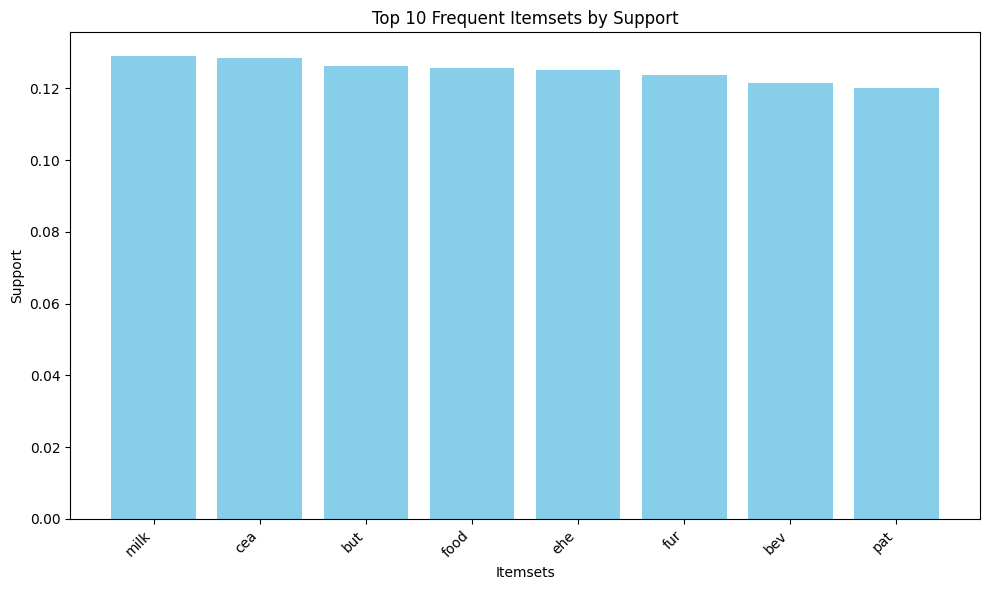

Top frequent itemsets:
   support    itemsets
0      1.0       (bev)
1      1.0       (but)
2      1.0       (cea)
3      1.0       (ehe)
4      1.0      (food)
5      1.0       (fur)
6      1.0      (milk)
7      1.0       (pat)
8      1.0  (bev, but)
9      1.0  (cea, bev)
Top 10 Association Rules:
       antecedents                            consequents  support  \
6049         (but)  (pat, fur, cea, food, bev, milk, ehe)      1.0   
0            (bev)                                  (but)      1.0   
6033  (food, milk)         (pat, fur, cea, bev, ehe, but)      1.0   
6032   (food, bev)        (pat, fur, cea, milk, ehe, but)      1.0   
6031    (cea, but)       (pat, fur, food, bev, milk, ehe)      1.0   
6030    (cea, ehe)       (pat, fur, food, bev, milk, but)      1.0   
6029   (cea, milk)        (pat, fur, food, bev, ehe, but)      1.0   
6028    (cea, bev)       (pat, fur, food, milk, ehe, but)      1.0   
6027   (cea, food)        (pat, fur, bev, milk, ehe, but)      1.0  

c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlxtend\frequent_patterns\association_rules.py:186: RuntimeWarning: invalid value encountered in divide
  cert_metric = np.where(certainty_denom == 0, 0, certainty_num / certainty_denom)


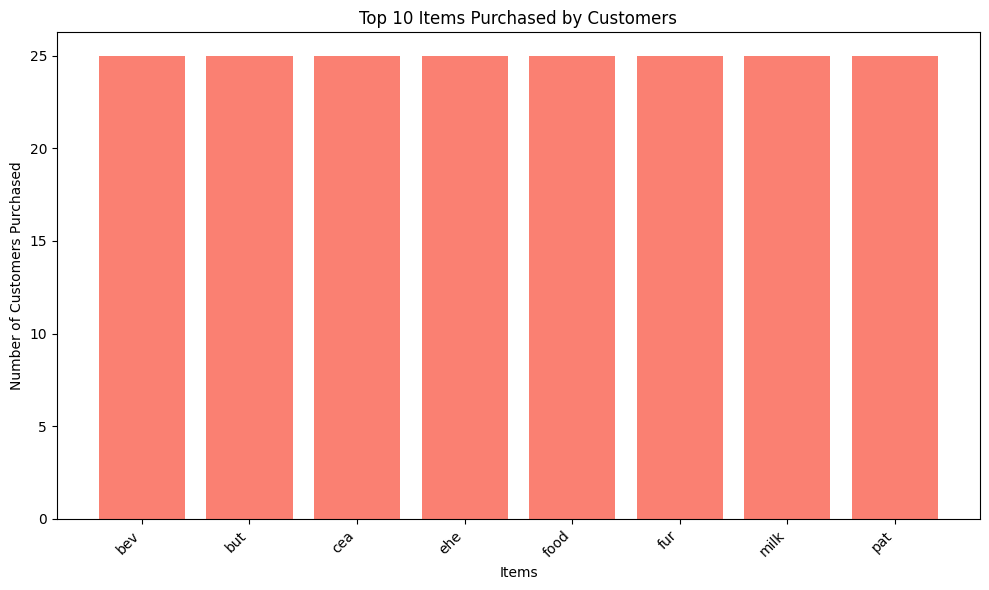

 Top 4 Interesting Association Rules 

Rule 6050: Customers who buy [but] also tend to buy [pat, fur, cea, food, bev, milk, ehe].
  - Support: 1.000 (fraction of all transactions that contain both items)
  - Confidence: 1.000 (chance of buying [pat, fur, cea, food, bev, milk, ehe] given [but])
  - Lift: 1.000 (how much more likely these items occur together than random chance)

Rule 1: Customers who buy [bev] also tend to buy [but].
  - Support: 1.000 (fraction of all transactions that contain both items)
  - Confidence: 1.000 (chance of buying [but] given [bev])
  - Lift: 1.000 (how much more likely these items occur together than random chance)

Rule 6034: Customers who buy [food, milk] also tend to buy [pat, fur, cea, bev, ehe, but].
  - Support: 1.000 (fraction of all transactions that contain both items)
  - Confidence: 1.000 (chance of buying [pat, fur, cea, bev, ehe, but] given [food, milk])
  - Lift: 1.000 (how much more likely these items occur together than random chance)

Ru

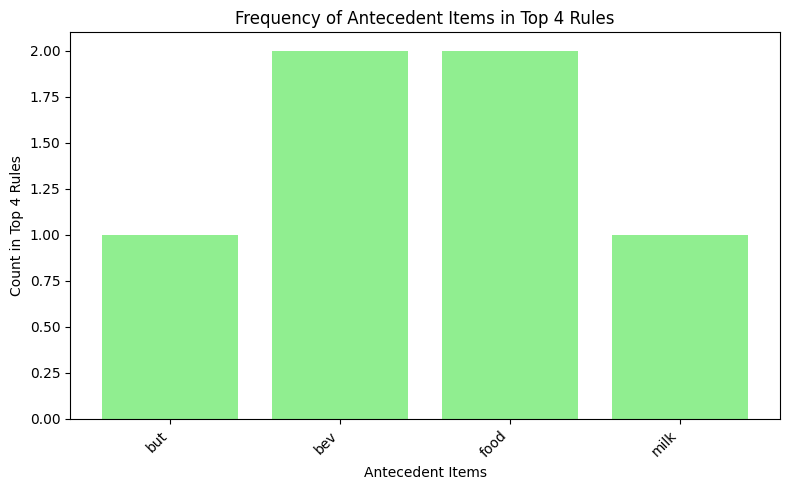

In [2]:
#Association Rule Mining using Apriori Algorithm Algorithm Assignment
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns   

from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder

# Load the dataset
data = pd.read_csv('C:/Users/Admin/OneDrive/Documents/USIU/Datawarehousing/Assignments/New folder/data/retail_store_sales.csv')

#Reset the index permanently and start from 1
data.reset_index(drop=True, inplace=True)  # dropping the old index
data.index += 1  #index will start from 1
print(data.head())
print("Data information: ")
print(data.info())
print("Data description: ")
print(data.describe())

# Data Preprocessing
# Check for missing values
print("Missing values in each column: ")
print(data.isnull().sum())
data.dropna(inplace=True)

# Check for duplicates
print("Number of duplicate rows: ", data.duplicated().sum())
data.drop_duplicates(inplace=True)


#Cleaning the data
#Drop rows where 'Item' is missing
data_clean = data.dropna(subset=['Item']).copy()

# Extract item name after the last underscore
data_clean['Item'] = data_clean['Item'].apply(lambda x: x.split('_')[-1].lower())

#Fill missing numeric columns with 0
numeric_cols = ['Price Per Unit', 'Quantity', 'Total Spent', 'Discount Applied']
data_clean[numeric_cols] = data_clean[numeric_cols].fillna(0)

#Verify cleaning
print("Missing values after the cleaning process:")
print(data_clean.isnull().sum())

# Normalize 'Item' names to avoid duplicates due to casing/spacing
data_clean['Item'] = data_clean['Item'].str.strip()     # removing leading/trailing spaces
data_clean['Item'] = data_clean['Item'].str.lower()     # converting everything to lowercase

#Verify
print("New shape of the cleaned data:", data_clean.shape)
print(data_clean.head())

# Prepare data for association rule mining
transactions = data_clean.groupby('Transaction ID')['Item'].apply(list)
transactions = transactions.values.tolist()

#Show sample transactions
print("Sample transactions: ", transactions[:5])    

#Frequent Itemset Mining
#Using Apriori Algorithm
# Convert transactions to one-hot encoded DataFrame
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

# Apply Apriori Algorithm
#Find frequent itemsets with minimum support 0.01 (1%)
frequent_itemsets = apriori(df_encoded, min_support=0.01, use_colnames=True)

#Sort frequent itemsets by support in descending order
frequent_itemsets = frequent_itemsets.sort_values(by='support', ascending=False)
print(frequent_itemsets.head(10))
print("Frequent Itemsets using Apriori Algorithm: ")
print(frequent_itemsets.head(10))

#Visualization of frequent itemsets
#Top 10 frequent itemsets
top10 = frequent_itemsets.head(10)

#Bar chart
plt.figure(figsize=(10,6))
plt.bar(range(len(top10)), top10['support'], color='skyblue')
plt.xticks(range(len(top10)), [', '.join(list(x)) for x in top10['itemsets']], rotation=45, ha='right')
plt.xlabel('Itemsets')
plt.ylabel('Support')
plt.title('Top 10 Frequent Itemsets by Support')
plt.tight_layout()
plt.show()


#Because of rules not being generated with apriori at higher support, we will lower the support threshold and try again.
# Generate association rules
# Create transactions grouped by Customer ID
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

#Grouping items by Customer ID
transactions_by_customer = data_clean.groupby('Customer ID')['Item'].apply(list).tolist()

#One-hot encode transactions
te = TransactionEncoder()
te_ary = te.fit(transactions_by_customer).transform(transactions_by_customer)
df_encoded_cust = pd.DataFrame(te_ary, columns=te.columns_)

#Generate frequent itemsets with low support
frequent_itemsets_cust = apriori(df_encoded_cust, min_support=0.005, use_colnames=True)
print("Top frequent itemsets:")
print(frequent_itemsets_cust.sort_values('support', ascending=False).head(10))

#Generate association rules from all frequent itemsets
rules = association_rules(frequent_itemsets_cust, metric="confidence", min_threshold=0.1)

#Keep only rules with 1+ items in antecedent and consequent
rules = rules[rules['antecedents'].apply(lambda x: len(x) > 0) & rules['consequents'].apply(lambda x: len(x) > 0)]

#rules with 2+ total items (antecedent + consequent)
rules = rules[rules['antecedents'].apply(lambda x: len(x)) + rules['consequents'].apply(lambda x: len(x)) >= 2]

#ort rules by lift
rules = rules.sort_values('lift', ascending=False)

#Display top 10 rules
print("Top 10 Association Rules:")
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))

# Count support of individual items across all customers
item_counts = df_encoded_cust.sum().sort_values(ascending=False)

# Take top 10 items
top_items = item_counts.head(10)

# Bar chart
plt.figure(figsize=(10,6))
plt.bar(top_items.index, top_items.values, color='salmon')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Items')
plt.ylabel('Number of Customers Purchased')
plt.title('Top 10 Items Purchased by Customers')
plt.tight_layout()
plt.show()

# Show Top 4 Interesting Rules
# ===============================

# Pick the top 4 rules by lift
top_rules = rules.head(4)

print(" Top 4 Interesting Association Rules \n")

for i, row in top_rules.iterrows():
    # Items that trigger the rule
    antecedents = ', '.join(list(row['antecedents']))
    # Items that are predicted to be bought next
    consequents = ', '.join(list(row['consequents']))
    # Capture the rule's statistics
    support = row['support']
    confidence = row['confidence']
    lift = row['lift']
    
    # Print the rule in beginner-friendly English
    print(f"Rule {i+1}: Customers who buy [{antecedents}] also tend to buy [{consequents}].")
    print(f"  - Support: {support:.3f} (fraction of all transactions that contain both items)")
    print(f"  - Confidence: {confidence:.3f} (chance of buying [{consequents}] given [{antecedents}])")
    print(f"  - Lift: {lift:.3f} (how much more likely these items occur together than random chance)\n")

# Bar Chart: Frequency of Antecedents in Top 4 Rules
# =====================================================

from collections import Counter

# Collecting all antecedents from top 4 rules
antecedent_items = []
for row in top_rules.itertuples():
    antecedent_items.extend(list(row.antecedents))

# Counting how many times each antecedent appears
antecedent_counts = Counter(antecedent_items)

#data for plotting
items = list(antecedent_counts.keys())
counts = list(antecedent_counts.values())

# Plot
plt.figure(figsize=(8,5))
plt.bar(items, counts, color='lightgreen')
plt.xlabel('Antecedent Items')
plt.ylabel('Count in Top 4 Rules')
plt.title('Frequency of Antecedent Items in Top 4 Rules')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
